In [1]:
import numpy as np
import matplotlib.pyplot as pl

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 700

In [2]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

In [3]:
lower_f = 20
upper_f = 2000 #?

## Parameter space

In [4]:
def beta_calc(f, M):
    M_temp = M*2e30
    return const*f**(8/3)*M_temp**(5/3)

In [5]:
fspace = np.linspace(20, 200, 1000)
Mspace = np.logspace(-5, -1, 1000)

[fgrid, Mgrid] = np.meshgrid(fspace, Mspace)
betaGrid = beta_calc(fgrid, Mgrid)

Text(0, 0.5, '$M_c$ ($M_\\odot$)')

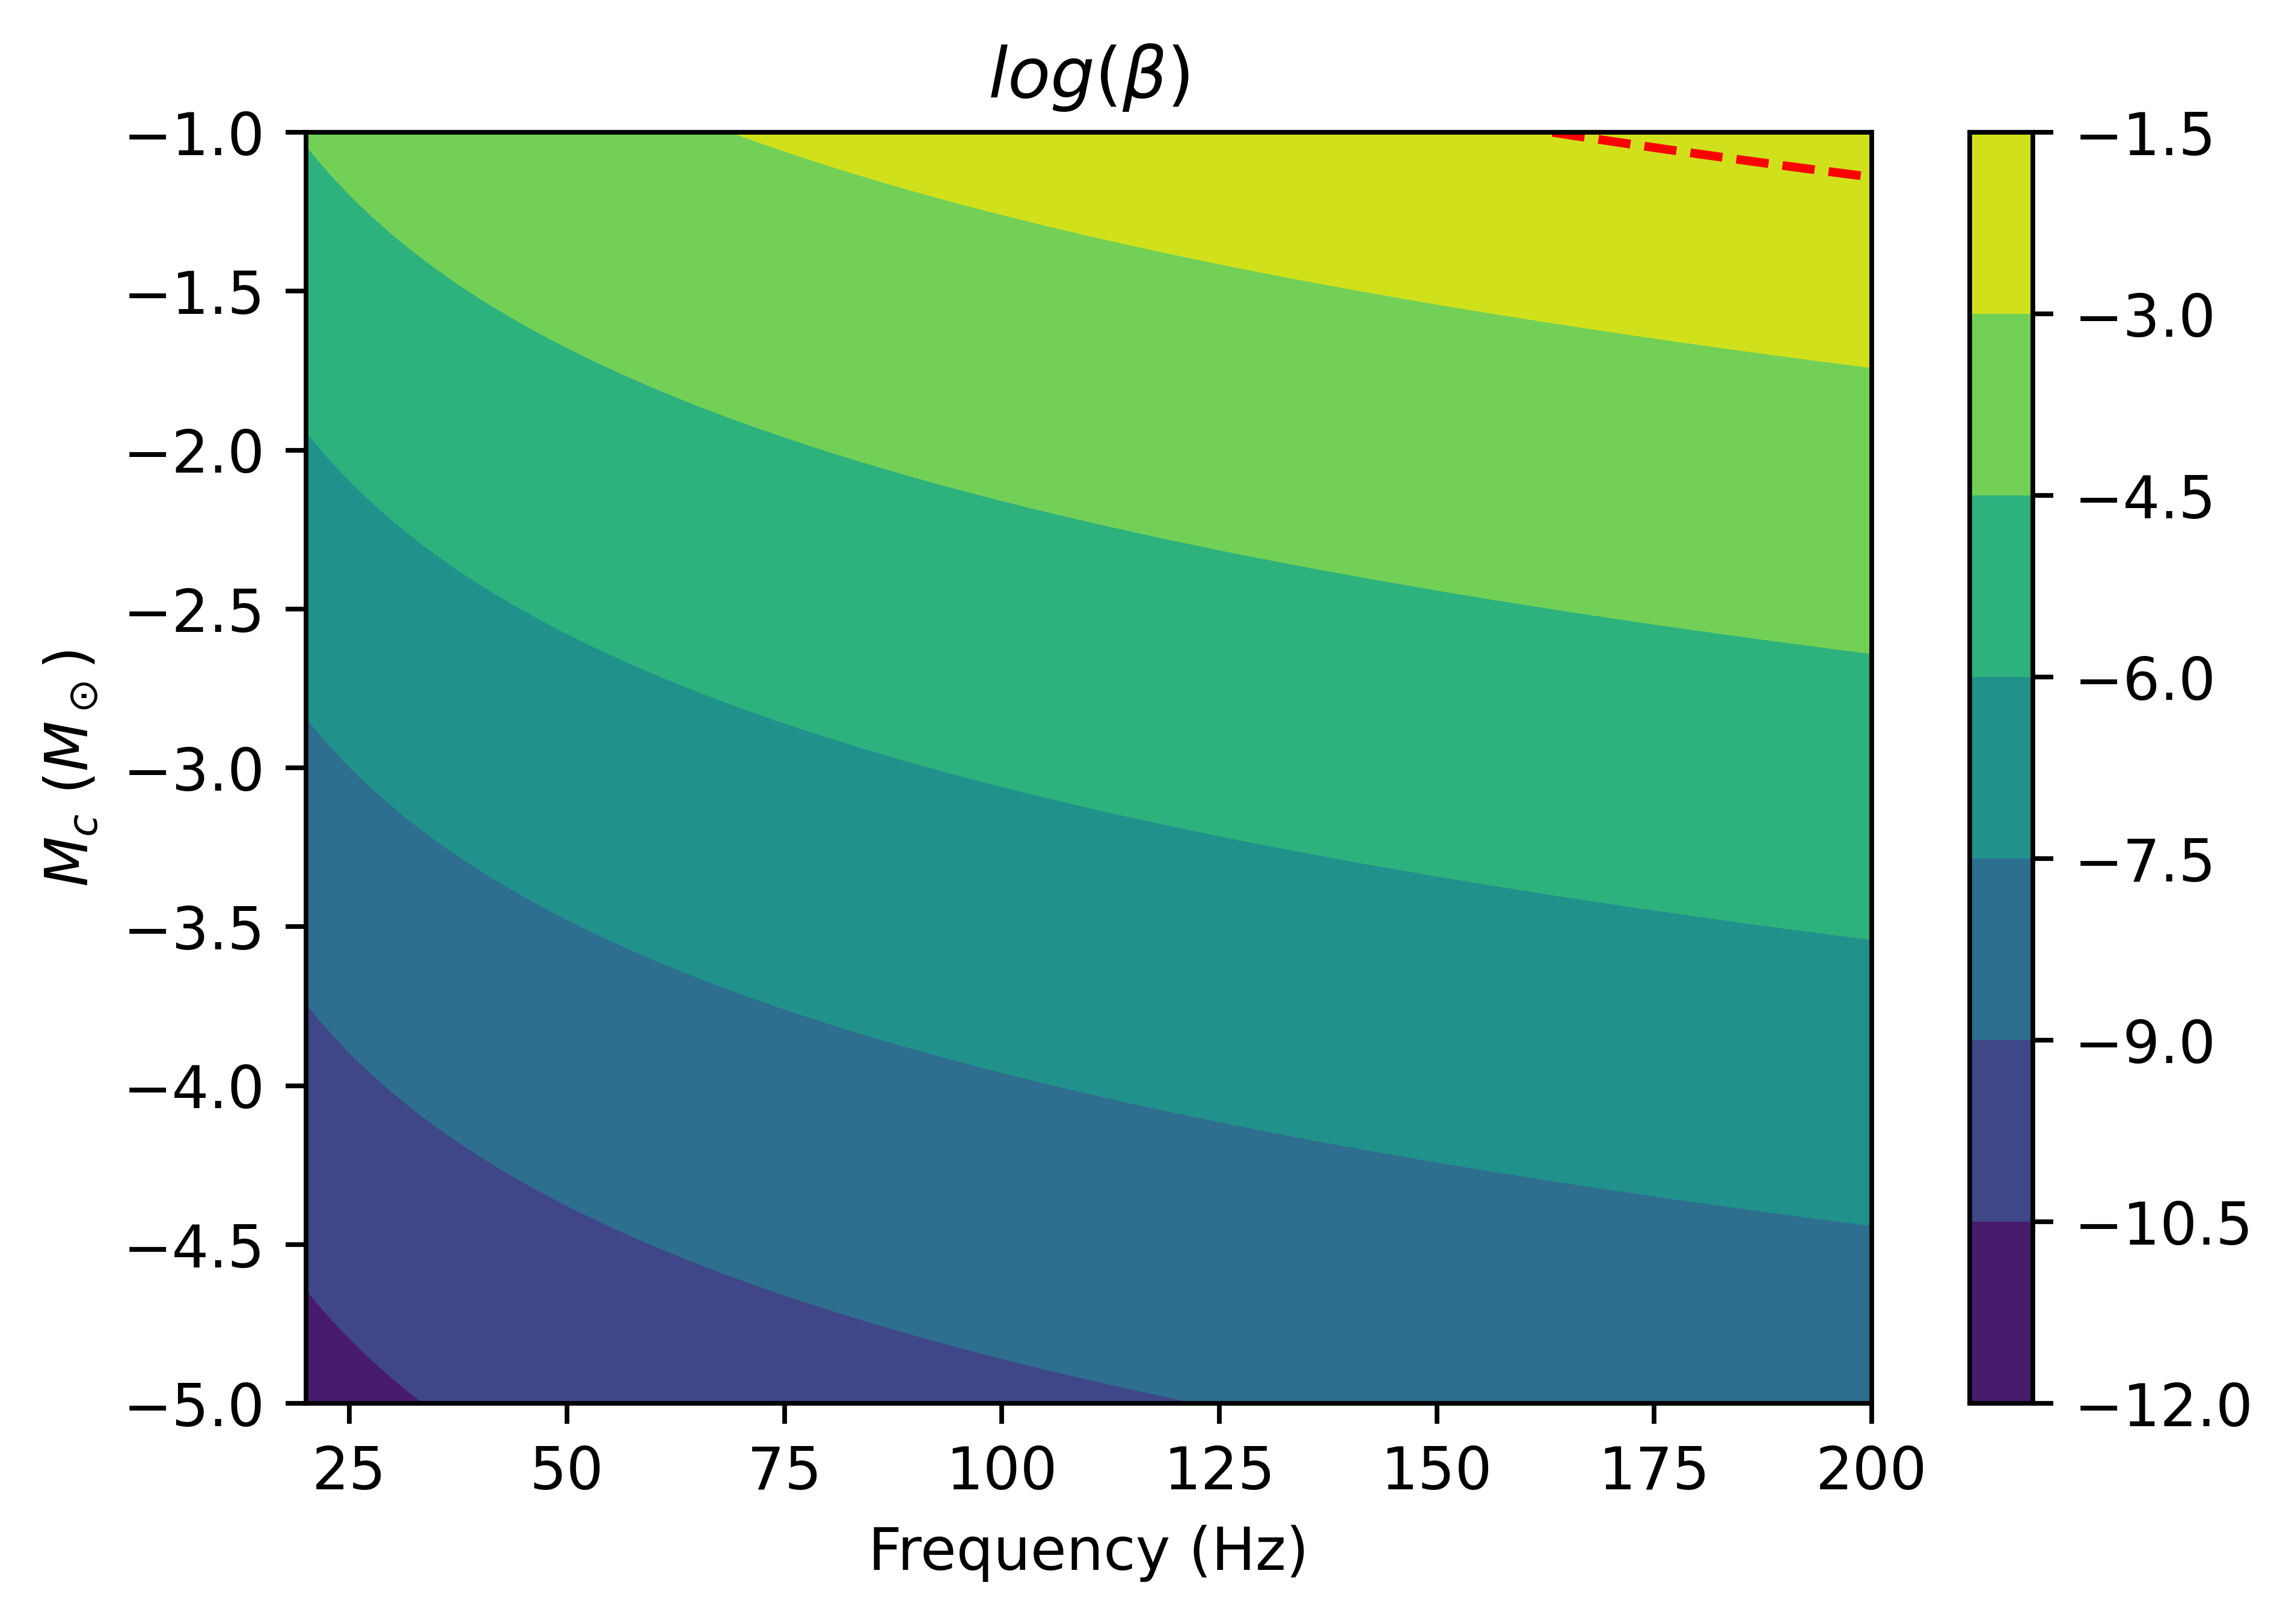

In [6]:
pl.contourf(fspace, np.log10(Mspace), np.log10(betaGrid))
pl.colorbar()
pl.contour(fspace, np.log10(Mspace), np.log10(betaGrid), levels=[-2], colors='r', linestyles='--')
pl.title(r'$log(\beta)$')
pl.xlabel("Frequency (Hz)")
pl.ylabel(r'$M_c$ ($M_\odot$)')

In [7]:
def t_max_calc(f0, M, f_max):
    temp0 = (M/1e-2)**(-5/3)
    temp1 = (f0/200)**(-8/3) - (f_max/200)**(-8/3)
    return 1e3*temp0*temp1

def t_max_calc1(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

In [8]:
t_max_calc(20, 0.353, 200)

1219.2857249395502

In [9]:
tMax_grid = t_max_calc(fgrid, Mgrid, upper_f)

$$ d = \sqrt{\frac{5.737 \times 10^{-5}}{\lambda^* T_{max}} }
\frac{c\beta}{f_0^2} 
\sqrt{\int_{t0}^{t0+T_{max}} \frac{(1-\frac{8}{3}\beta t)^{-1/2}}{S_n(f(t))}}$$

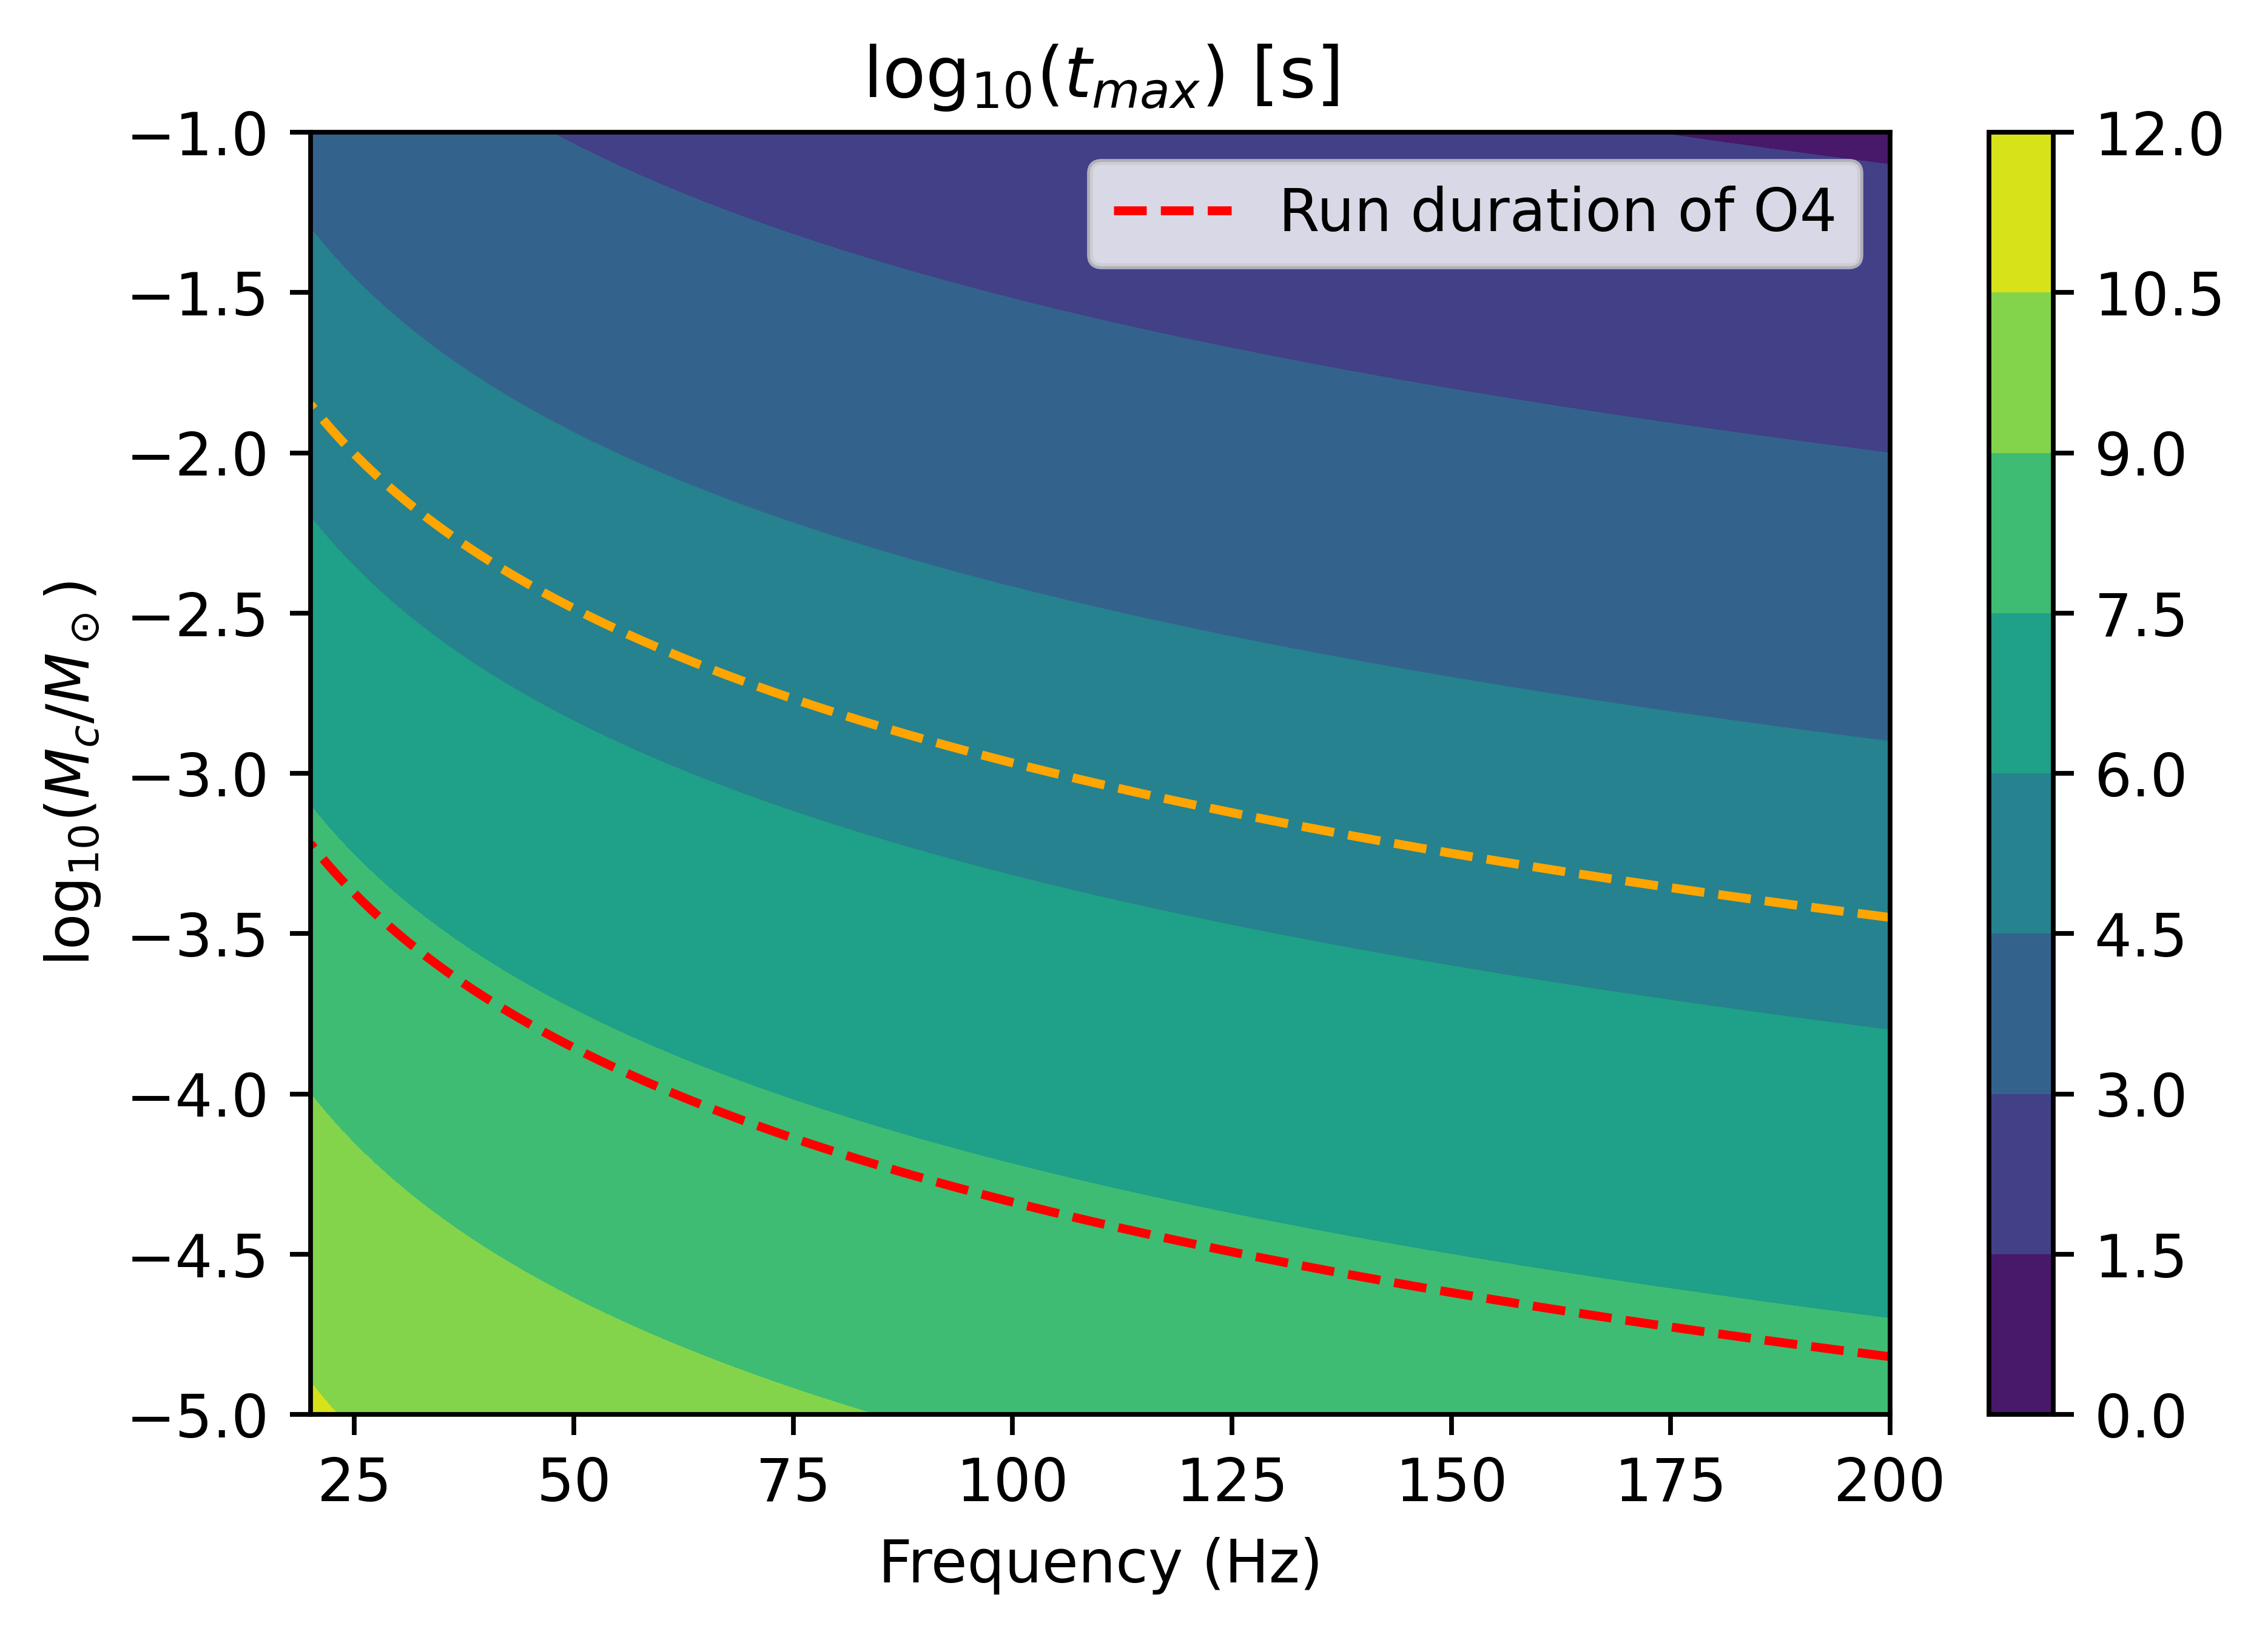

In [20]:
pl.contourf(fspace, np.log10(Mspace), np.log10(tMax_grid))
pl.colorbar()
pl.contour(fspace, np.log10(Mspace), np.log10(tMax_grid), levels=[np.log10(2.6e5)], colors='orange', linestyles='--')
pl.contour(fspace, np.log10(Mspace), np.log10(tMax_grid), levels=[np.log10(5e7)], colors='r', linestyles='--')
pl.title(r'log$_{10}(t_{max})$ [s]')
pl.xlabel("Frequency (Hz)")
pl.ylabel(r'log$_{10}(M_c/M_\odot)$')
from matplotlib.lines import Line2D
line = Line2D([0], [0], label='Run duration of O4', color='r', ls = '--')
pl.legend(handles = [line])

In [35]:
def f_calc(f0, t, beta):
    return f0*np.power(1-8/3*beta*t,-3/8)

In [36]:
fMax_grid = f_calc(fgrid, tMax_grid, betaGrid)

Text(0, 0.5, 'log$_{10}(M_c/M_\\odot)$')

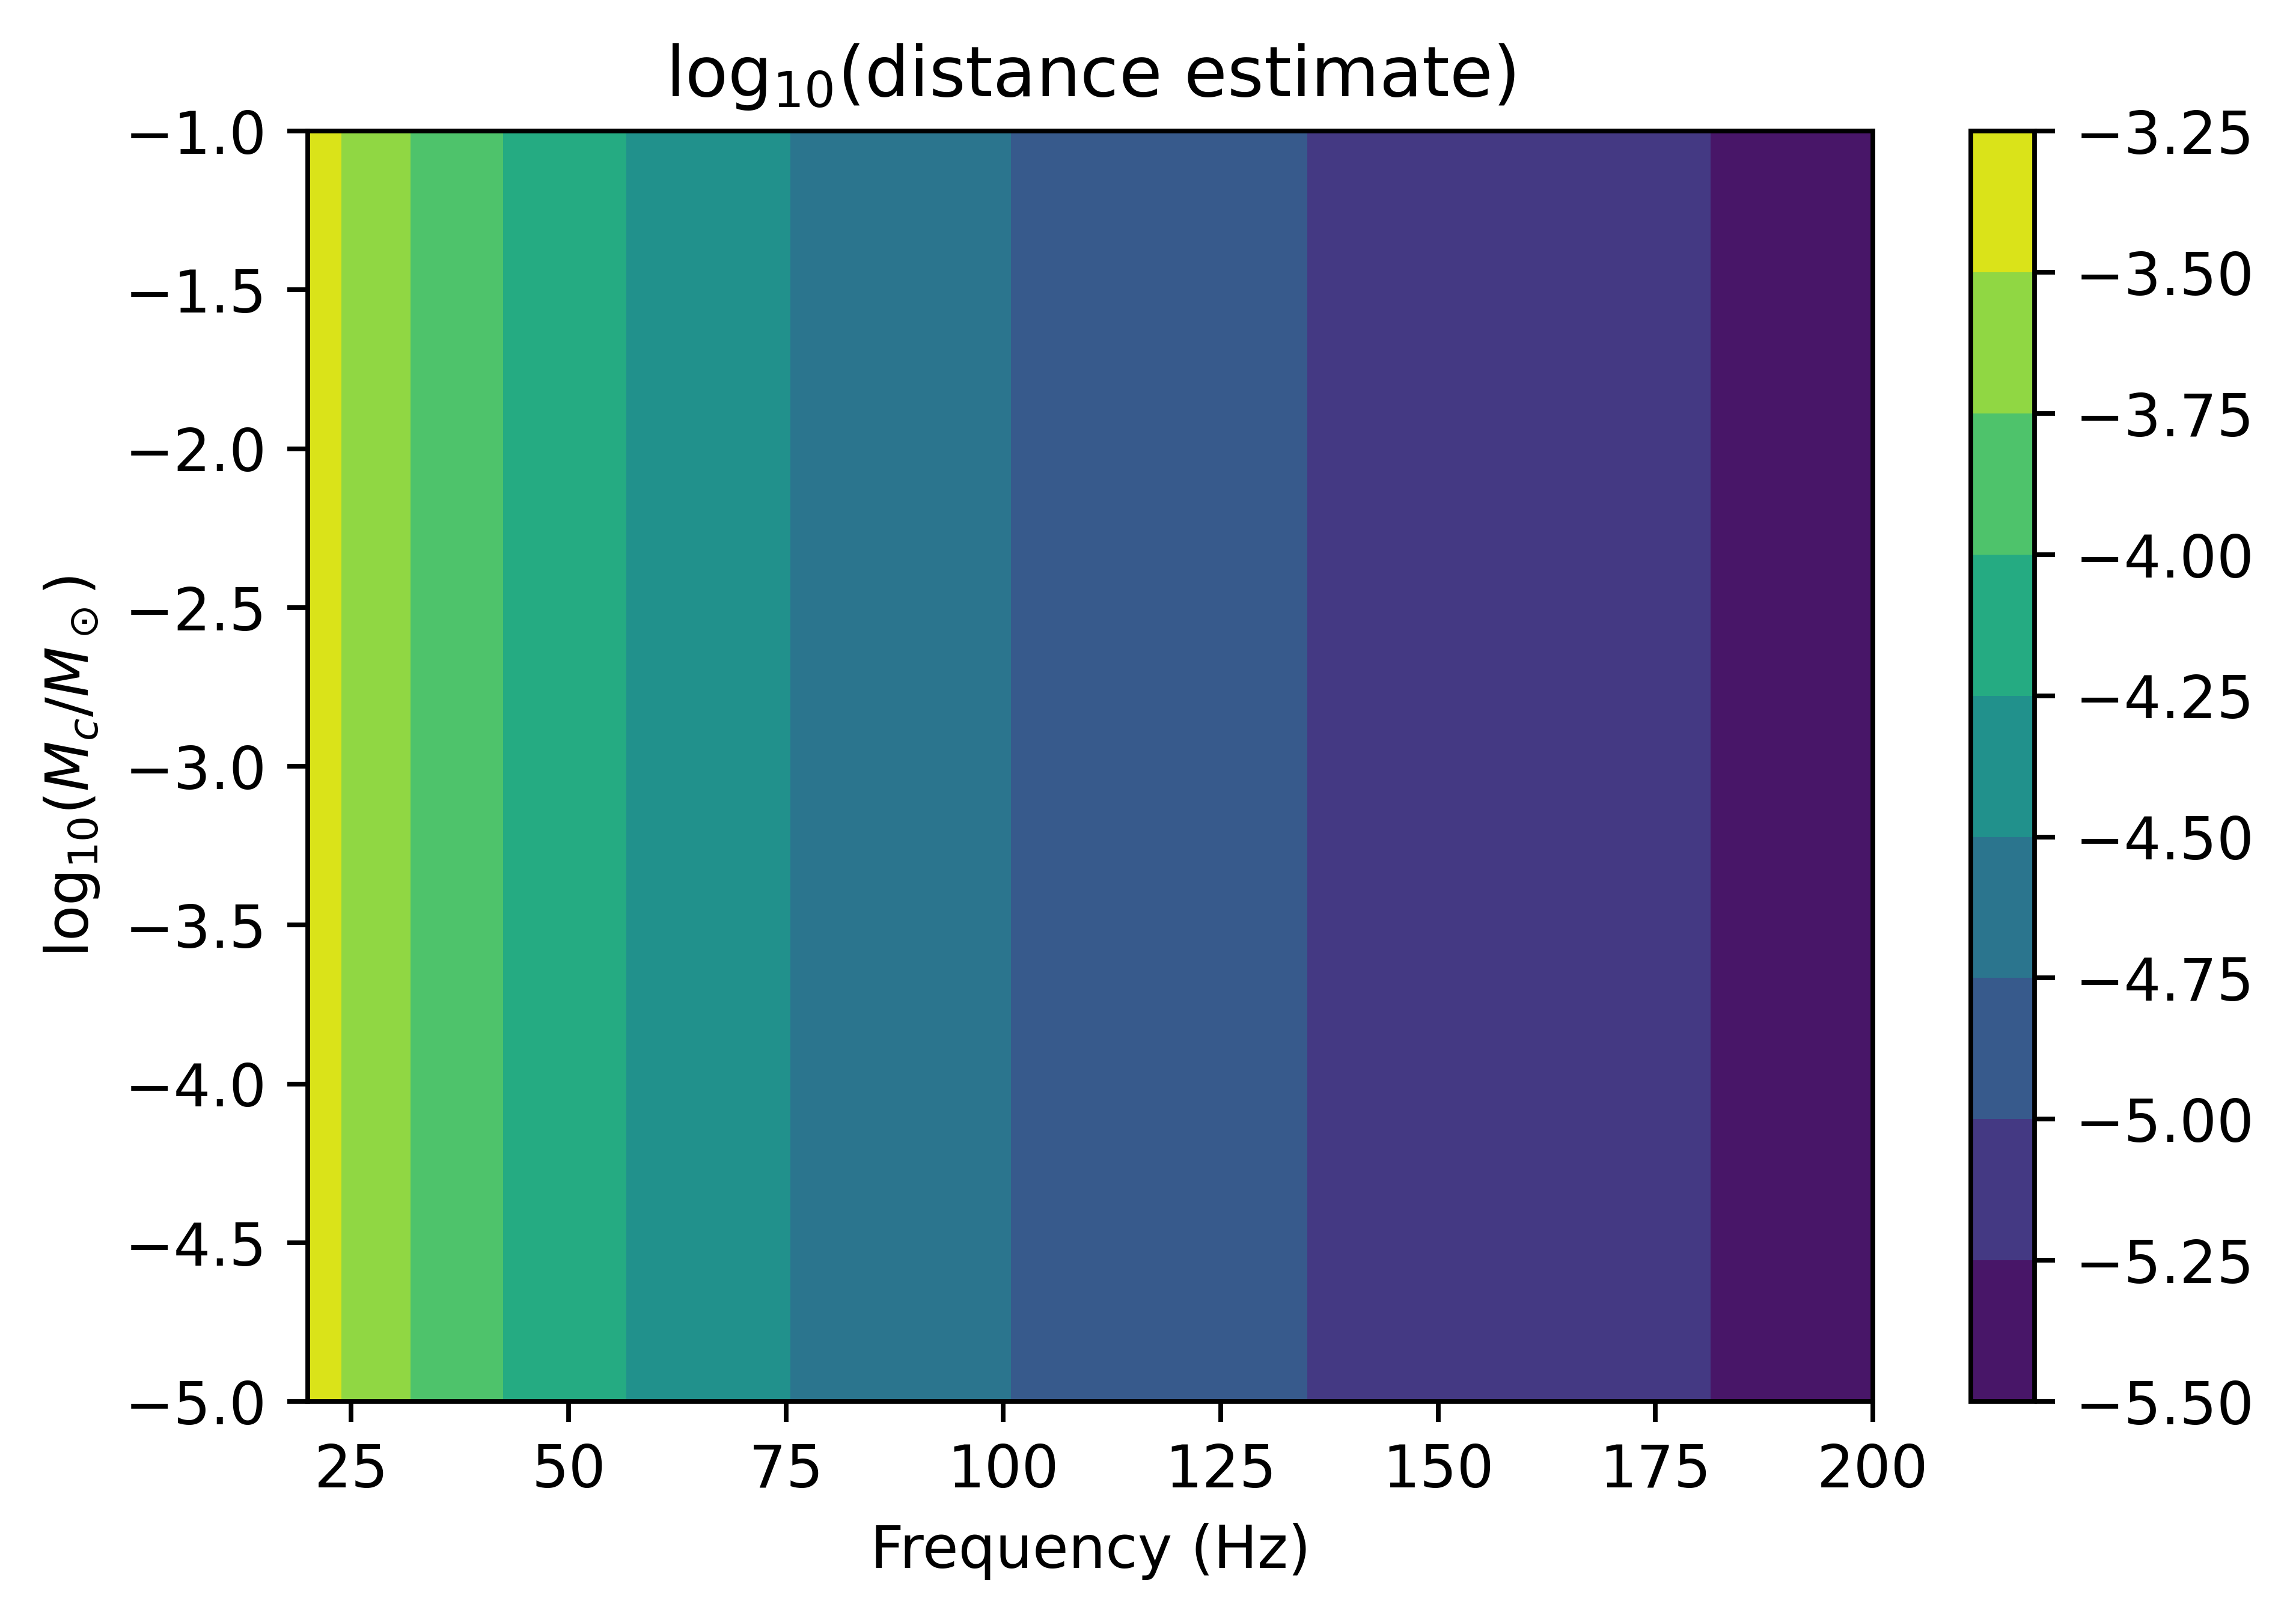

In [23]:
sens_estimate = np.sqrt(tMax_grid)*betaGrid/(fgrid**2)*np.sqrt(3/(4*betaGrid)*(1-8/3*betaGrid*tMax_grid)**0.5)
pl.contourf(fspace, np.log10(Mspace), np.log10(sens_estimate))
pl.colorbar()
pl.title(r'log$_{10}($distance estimate)')
pl.xlabel("Frequency (Hz)")
pl.ylabel(r'log$_{10}(M_c/M_\odot)$')

Text(0, 0.5, '$M_c$ ($M_\\odot$)')

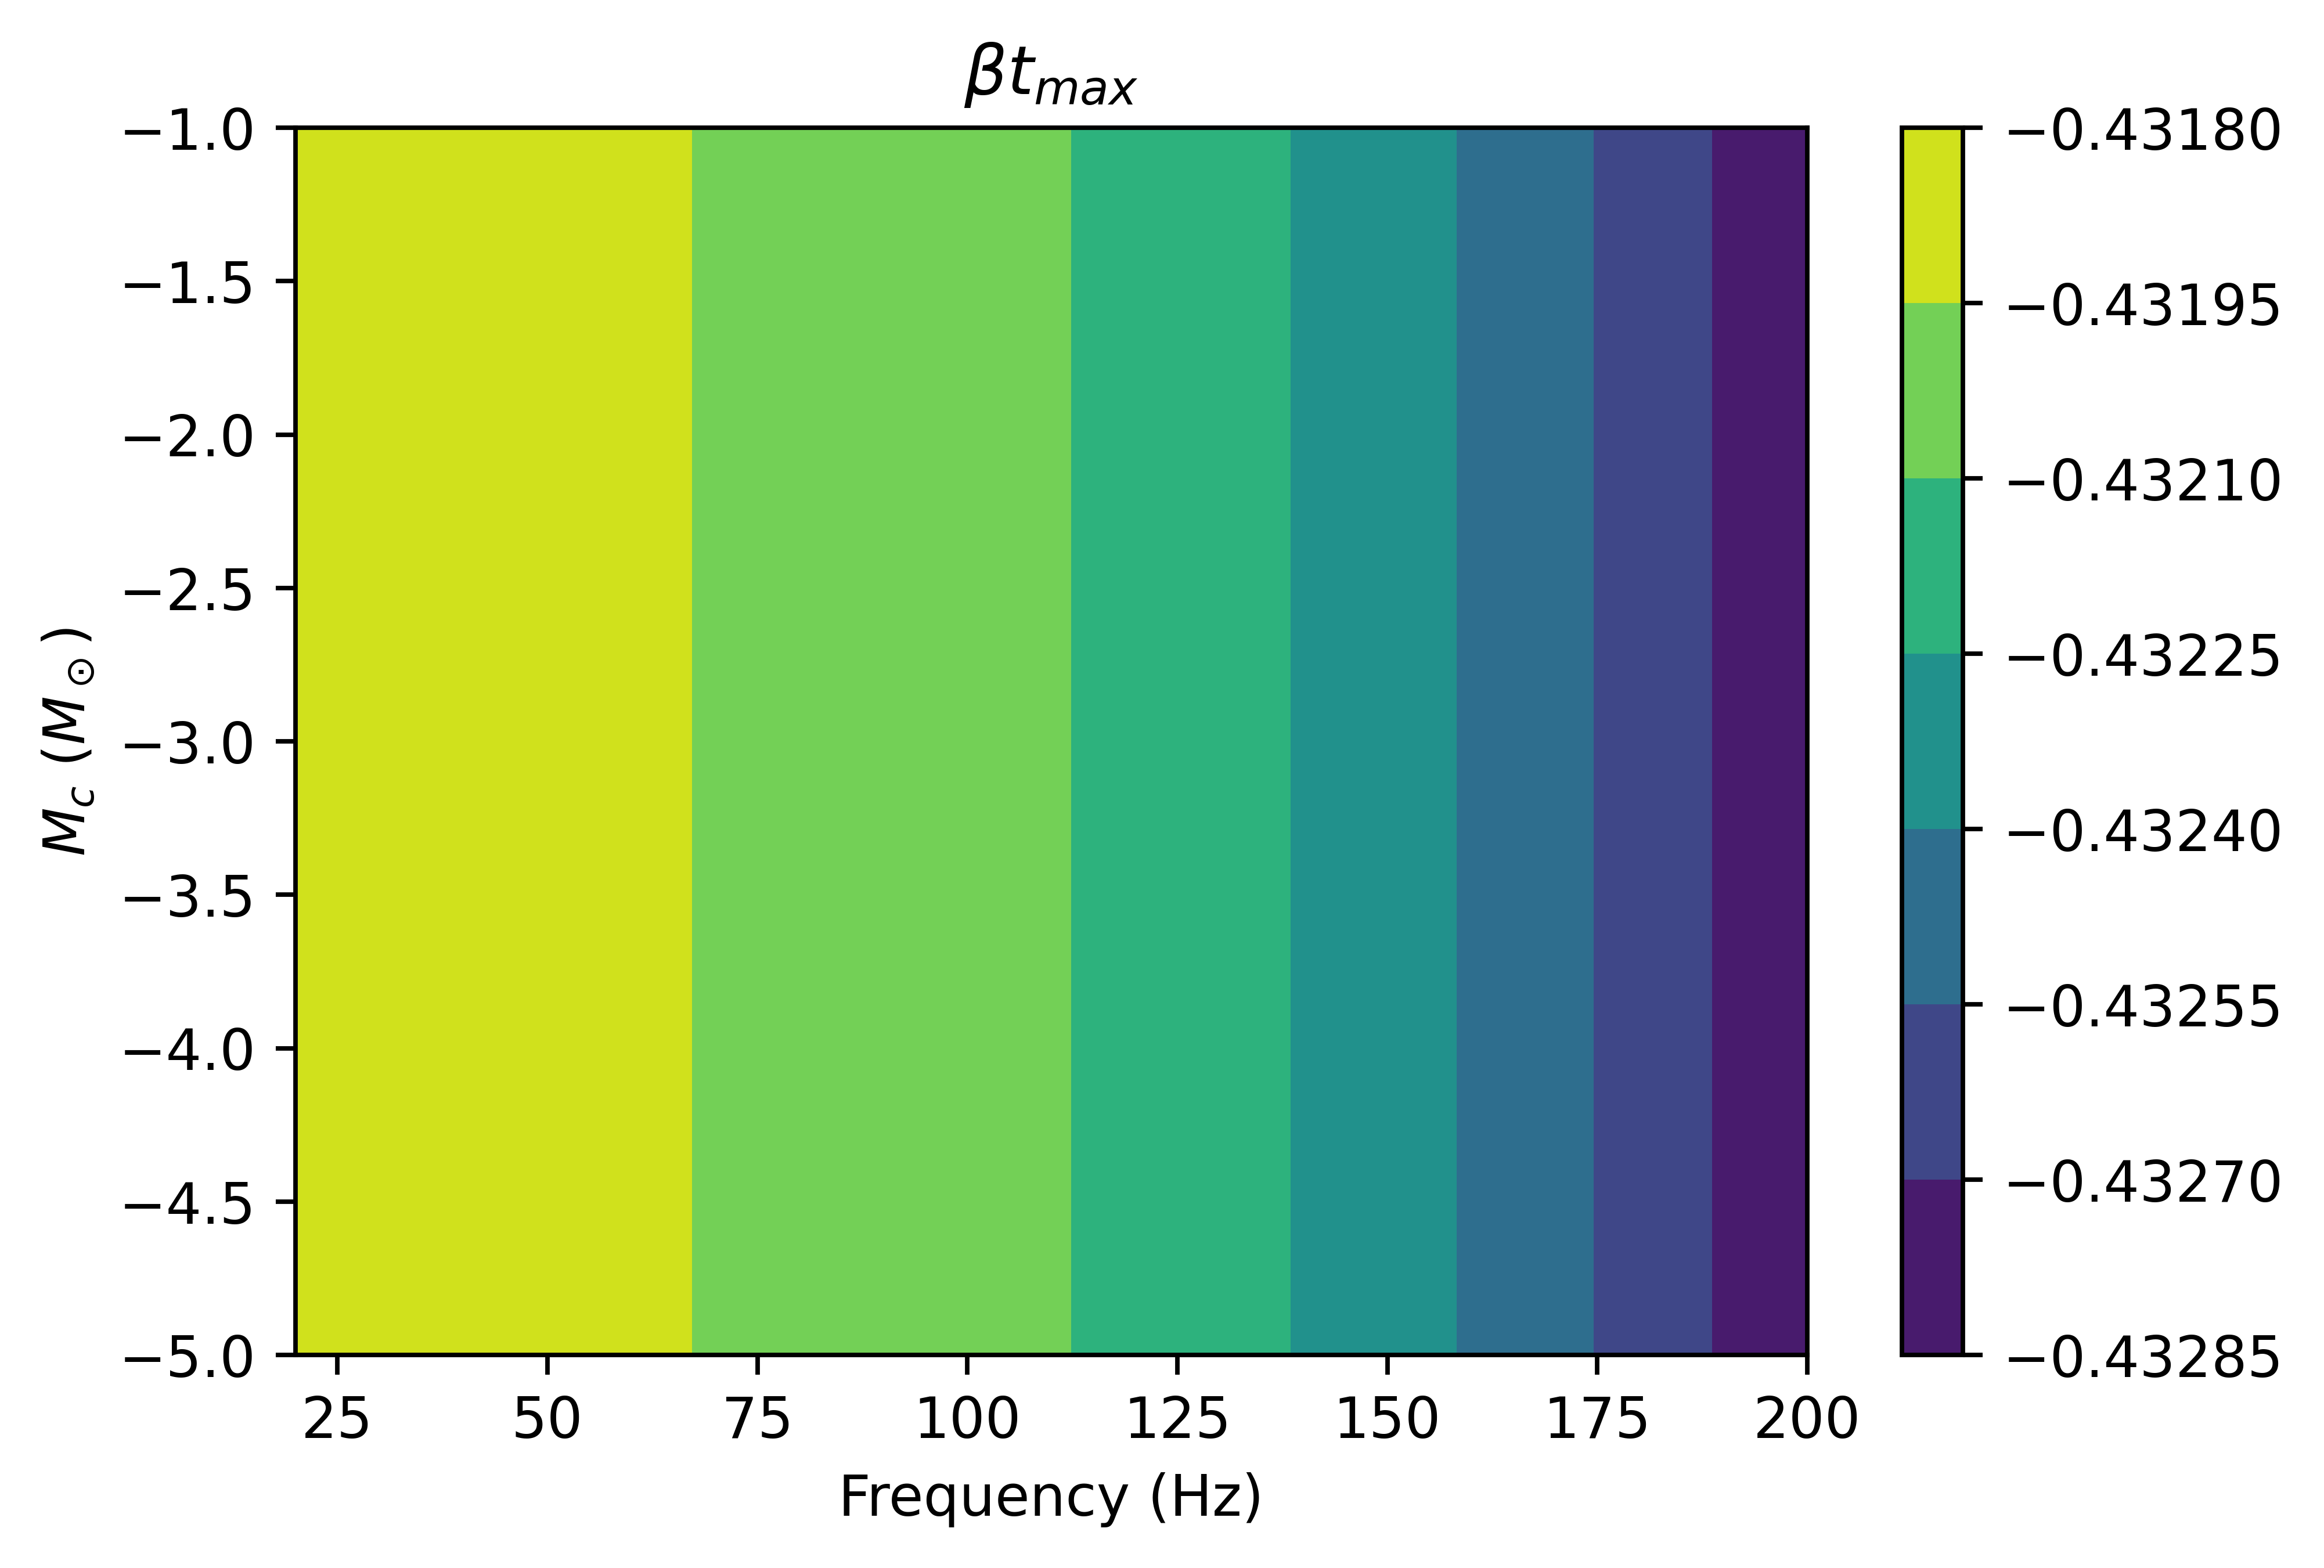

In [38]:
pl.contourf(fspace, np.log10(Mspace), np.log10(tMax_grid*betaGrid))
pl.colorbar()
pl.title(r'$\beta t_{max}$')
pl.xlabel("Frequency (Hz)")
pl.ylabel(r'$M_c$ ($M_\odot$)')